# **Factory Sensor Incident Prediction**

## **1. Imports**

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              roc_auc_score, classification_report)
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import STL
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from itertools import product

## **2. Synthetic Data Generation**

2000 days of factory sensor data (vibration, temperature, pressure) with a shared seasonal component.  
**18 random incident windows** of 3–10 days are injected with anomalous sensor readings


In [2]:
np.random.seed(42)
n = 2000
dates = pd.date_range(start='2019-01-01', periods=n, freq='D')
t = np.arange(n)

# Seasonal component shared across all sensors
season = np.sin(2 * np.pi * t / 365)

vibration   = 3.5 + 0.5 * season + np.random.normal(0, 0.2, n)
temperature = 70  + 8   * season + np.random.normal(0, 1.5, n)
pressure    = 5.0 + 0.3 * season + np.random.normal(0, 0.15, n)

# Inject 18 random incident windows of 3-10 days each
incident_mask = np.zeros(n, dtype=bool)
for _ in range(18):
    start = np.random.randint(50, n - 50)
    duration = np.random.randint(3, 10)
    incident_mask[start:start+duration] = True
    vibration[start:start+duration] += np.random.uniform(4, 8, duration)
    temperature[start:start+duration] += np.random.uniform(15, 30, duration)
    pressure[start:start+duration] -= np.random.uniform(1.5, 2.5, duration)

df = pd.DataFrame({
    'date':        dates,
    'vibration':   vibration.round(2),
    'temperature': temperature.round(2),
    'pressure':    pressure.round(2),
    'incident':    incident_mask.astype(int)
}).set_index('date')

print(f"Dataset: {len(df)} rows, incidents: {df['incident'].sum()} ({df['incident'].mean()*100:.1f}%)")

Dataset: 2000 rows, incidents: 92 (4.6%)


## **3. Data Visualization**


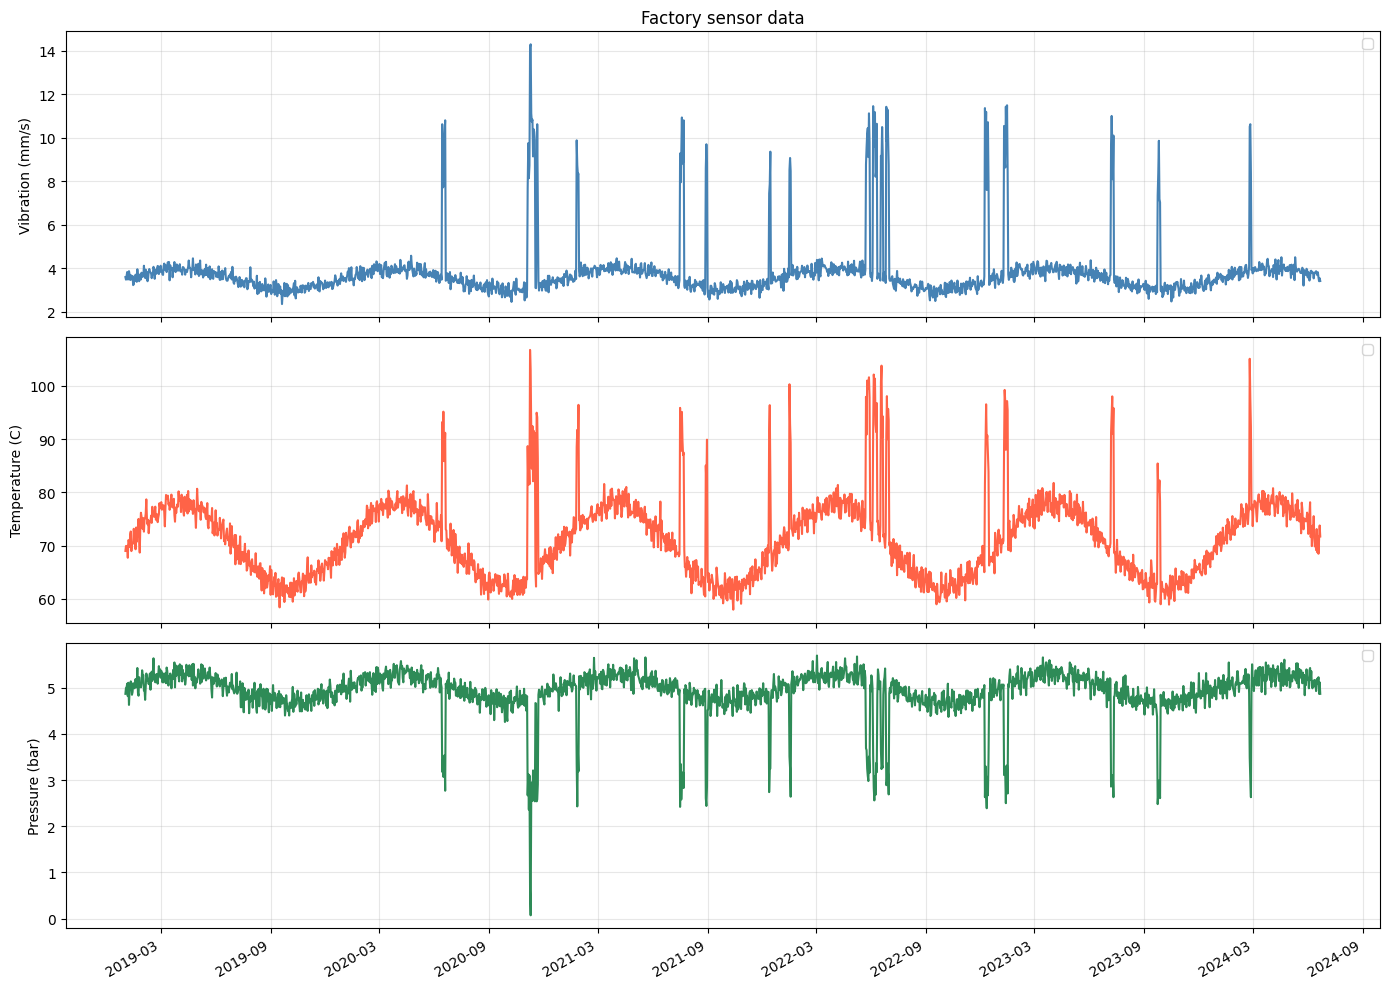

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for ax, (col, label, color) in zip(axes, [
    ('vibration',   'Vibration (mm/s)', 'steelblue'),
    ('temperature', 'Temperature (C)',  'tomato'),
    ('pressure',    'Pressure (bar)',   'seagreen'),
]):
    ax.plot(df.index, df[col], color=color)
    ax.set_ylabel(label)
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right')

axes[0].set_title('Factory sensor data')
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## **4. Feature Engineering**

Two types of features are constructed:

**Trend features** — STL decomposition extracts the slow-moving trend component for each sensor.  
`robust=True` reduces the influence of anomalous incident spikes on the trend estimate.

**Cyclic calendar features** — sin/cos encoding of day-of-month, month, and day-of-year  
to capture seasonality without ordinal artifacts.


In [4]:
base_features = ['vibration', 'temperature', 'pressure']

for col in base_features:
    stl = STL(df[col], period=365, robust=True)  # robust=True reduces the influence of outliers
    res = stl.fit()
    df[f'{col}_trend'] = res.trend

df['day_sin']   = np.sin(2 * np.pi * df.index.day / 31)
df['day_cos']   = np.cos(2 * np.pi * df.index.day / 31)
df['month_sin'] = np.sin(2 * np.pi * df.index.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df.index.month / 12)
df['doy_sin']   = np.sin(2 * np.pi * df.index.dayofyear / 365)
df['doy_cos']   = np.cos(2 * np.pi * df.index.dayofyear / 365)

## **5. Sliding Window Formulation**


In [5]:
W = 7   # lookback window in days
H = 3   # forecast horizon in days

# We include both raw sensor values and their STL trends in the window
# Cyclic features are appended once per sample (not repeated over the window)
window_features = base_features + [f'{c}_trend' for c in base_features]
cyclic_features = ['day_sin', 'day_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos']

X_flat, X_seq, y, dates_idx = [], [], [], []
# X_flat: flattened 1D vector for RF, SVM
# X_seq:  3D array (samples, timesteps, features) for LSTM

for i in range(W, len(df) - H):
    window_vals = df[window_features].iloc[i-W:i].values  # (W, n_window_features)
    cyclic_vals = df[cyclic_features].iloc[i].values  # (n_cyclic,)
    label = df['incident'].iloc[i:i+H].max()  # 1 if any incident in horizon

    X_flat.append(np.concatenate([window_vals.flatten(), cyclic_vals]))
    X_seq.append(window_vals)
    y.append(label)
    dates_idx.append(df.index[i])

X_flat = np.array(X_flat)
X_seq = np.array(X_seq)
y = np.array(y)
dates_idx = np.array(dates_idx)

## **6. Train / Test Split & Normalization**


In [6]:
split = int(len(X_flat) * 0.8)

X_train_f, X_test_f = X_flat[:split], X_flat[split:]
X_train_s, X_test_s = X_seq[:split], X_seq[split:]
y_train, y_test = y[:split], y[split:]
dates_test = dates_idx[split:]

# Normalize
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_f)
X_test_sc = scaler.transform(X_test_f)

mean_s = X_train_s.mean(axis=0)
std_s = X_train_s.std(axis=0) + 1e-8
X_train_s_sc = (X_train_s - mean_s) / std_s
X_test_s_sc = (X_test_s  - mean_s) / std_s

## **7. Random Forest**

In [8]:
tscv = TimeSeriesSplit(n_splits=5)
rf_results = []

for n_est, depth in product([50, 100, 200], [3, 5, 8]):
    scores = []
    for tr, val in tscv.split(X_train_f):
        m = RandomForestClassifier(n_estimators=n_est, max_depth=depth)
        m.fit(X_train_f[tr], y_train[tr])
        scores.append(f1_score(y_train[val], m.predict(X_train_f[val]), zero_division=0))
    rf_results.append({'n_estimators': n_est, 'max_depth': depth, 'f1_cv': np.mean(scores)})

rf_df = pd.DataFrame(rf_results).sort_values('f1_cv', ascending=False)
best_rf_p = rf_df.iloc[0]
print(best_rf_p)

best_rf = RandomForestClassifier(
    n_estimators=int(best_rf_p['n_estimators']),
    max_depth=int(best_rf_p['max_depth']),
)
best_rf.fit(X_train_f, y_train)
pred_rf = best_rf.predict(X_test_f)

n_estimators    50.000000
max_depth        3.000000
f1_cv            0.308061
Name: 0, dtype: float64


## **8. SVM — Grid Search**


In [9]:
tscv_bal = TimeSeriesSplit(n_splits=5, test_size=int(len(X_train_sc) * 0.15))
svm_results = []

for C, kernel in product([0.1, 1, 10], ['rbf', 'linear']):
    scores = []
    for tr, val in tscv_bal.split(X_train_sc):
        # Skip folds that contain only one class - SVM requires both
        if len(np.unique(y_train[tr])) < 2 or len(np.unique(y_train[val])) < 2:
            continue
        m = SVC(C=C, kernel=kernel, random_state=42, class_weight='balanced')
        m.fit(X_train_sc[tr], y_train[tr])
        scores.append(f1_score(y_train[val], m.predict(X_train_sc[val]), zero_division=0))
    svm_results.append({'C': C, 'kernel': kernel,'f1_cv': np.mean(scores)})

svm_df = pd.DataFrame(svm_results).sort_values('f1_cv', ascending=False)
best_svm_p = svm_df.iloc[0]
print(best_svm_p)

best_svm = SVC(C=best_svm_p['C'], kernel=best_svm_p['kernel'], random_state=42, class_weight='balanced')
best_svm.fit(X_train_sc, y_train)
pred_svm = best_svm.predict(X_test_sc)

C              1.0
kernel         rbf
f1_cv     0.347338
Name: 2, dtype: object


## **9. LSTM**

In [10]:
neg, pos = np.bincount(y_train)
class_weight = {0: 1.0, 1: neg / pos}   # weight positive class by imbalance ratio

lstm_model = Sequential([
    LSTM(64, input_shape=(W, X_train_s_sc.shape[2]), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.fit(
    X_train_s_sc, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weight,
    verbose=1
)

pred_lstm = (lstm_model.predict(X_test_s_sc) > 0.5).astype(int).flatten()

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.7521 - loss: 0.9353 - val_accuracy: 0.1063 - val_loss: 0.9970
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8757 - loss: 0.8071 - val_accuracy: 0.8687 - val_loss: 0.7238
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8994 - loss: 0.7409 - val_accuracy: 0.6187 - val_loss: 0.7858
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9085 - loss: 0.7075 - val_accuracy: 0.8062 - val_loss: 0.6382
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9295 - loss: 0.6482 - val_accuracy: 0.6812 - val_loss: 0.5526
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9211 - loss: 0.5842 - val_accuracy: 0.6750 - val_loss: 0.6133
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8575 - loss: 0.5679 - val_accuracy: 0.6687 - val_loss: 0.5705
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8925 - loss: 0.5079 - val_accuracy: 0.6812 - va

## **10. Alert Threshold Selection**

The optimal threshold is found via the **Precision-Recall curve** by maximising F1-score on the test set

In [11]:
proba_rf = best_rf.predict_proba(X_test_f)[:, 1]
proba_svm = best_svm.decision_function(X_test_sc)
proba_lstm = lstm_model.predict(X_test_s_sc).flatten()

def best_threshold(y_true, proba):
    precision, recall, thresholds = precision_recall_curve(y_true, proba)
    f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
    best_idx = f1_scores[:-1].argmax()
    return thresholds[best_idx], precision[best_idx], recall[best_idx]

thresh_rf, p_rf, r_rf = best_threshold(y_test, proba_rf)
thresh_svm, p_svm, r_svm = best_threshold(y_test, proba_svm)
thresh_lstm, p_lstm, r_lstm = best_threshold(y_test, proba_lstm)

print(f"\nAlert Thresholds:")
print(f"Random Forest: {thresh_rf:.3f}  (precision={p_rf:.2f}, recall={r_rf:.2f})")
print(f"SVM: {thresh_svm:.3f}  (precision={p_svm:.2f}, recall={r_svm:.2f})")
print(f"LSTM: {thresh_lstm:.3f}  (precision={p_lstm:.2f}, recall={r_lstm:.2f})")

# apply best thresholds
pred_rf = (proba_rf >= thresh_rf).astype(int)
pred_svm = (proba_svm >= thresh_svm).astype(int)
pred_lstm = (proba_lstm >= thresh_lstm).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

Alert Thresholds:
Random Forest: 0.507  (precision=0.83, recall=0.53)
SVM: 0.158  (precision=0.88, recall=0.37)
LSTM: 0.876  (precision=0.89, recall=0.42)


## **11. Time-Series Metrics**

In [12]:
# time-series metrics

# Negative lag = model predicted BEFORE the incident started (ideal)
# Positive lag = model predicted AFTER the incident started (late)
# NaN = model missed this incident entirely

def ts_metrics(y_true, y_pred, name):
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_pred)
    except:
        auc = float('nan')

    lags, in_incident = [], False
    for i in range(len(y_true)):
        if y_true[i] == 1 and not in_incident:
            in_incident = True
            w_start = max(0, i - 5)
            w_end = min(len(y_pred), i + 5)
            pw = y_pred[w_start:w_end]
            if 1 in pw:
                lags.append(list(pw).index(1) - (i - w_start))
        elif y_true[i] == 0:
            in_incident = False

    return {
        'Model':             name,
        'Precision':         p,
        'Recall':            r,
        'F1':                f1,
        'ROC-AUC':           auc,
        'Avg Detection Lag': np.mean(lags) if lags else float('nan')
    }

all_models = [
    ('Random Forest',    pred_rf),
    ('SVM',              pred_svm),
    ('LSTM',             pred_lstm),
]

metrics_df = pd.DataFrame([ts_metrics(y_test, p, n) for n, p in all_models])
metrics_df = metrics_df.set_index('Model').round(3)
print("\nTime-Series Metrics on Test Set")
print(metrics_df.to_string())


Time-Series Metrics on Test Set
               Precision  Recall     F1  ROC-AUC  Avg Detection Lag
Model                                                              
Random Forest      0.833   0.526  0.645    0.761                3.0
SVM                0.875   0.368  0.519    0.683                3.0
LSTM               0.889   0.421  0.571    0.709                3.0


## **12. Results Visualization**

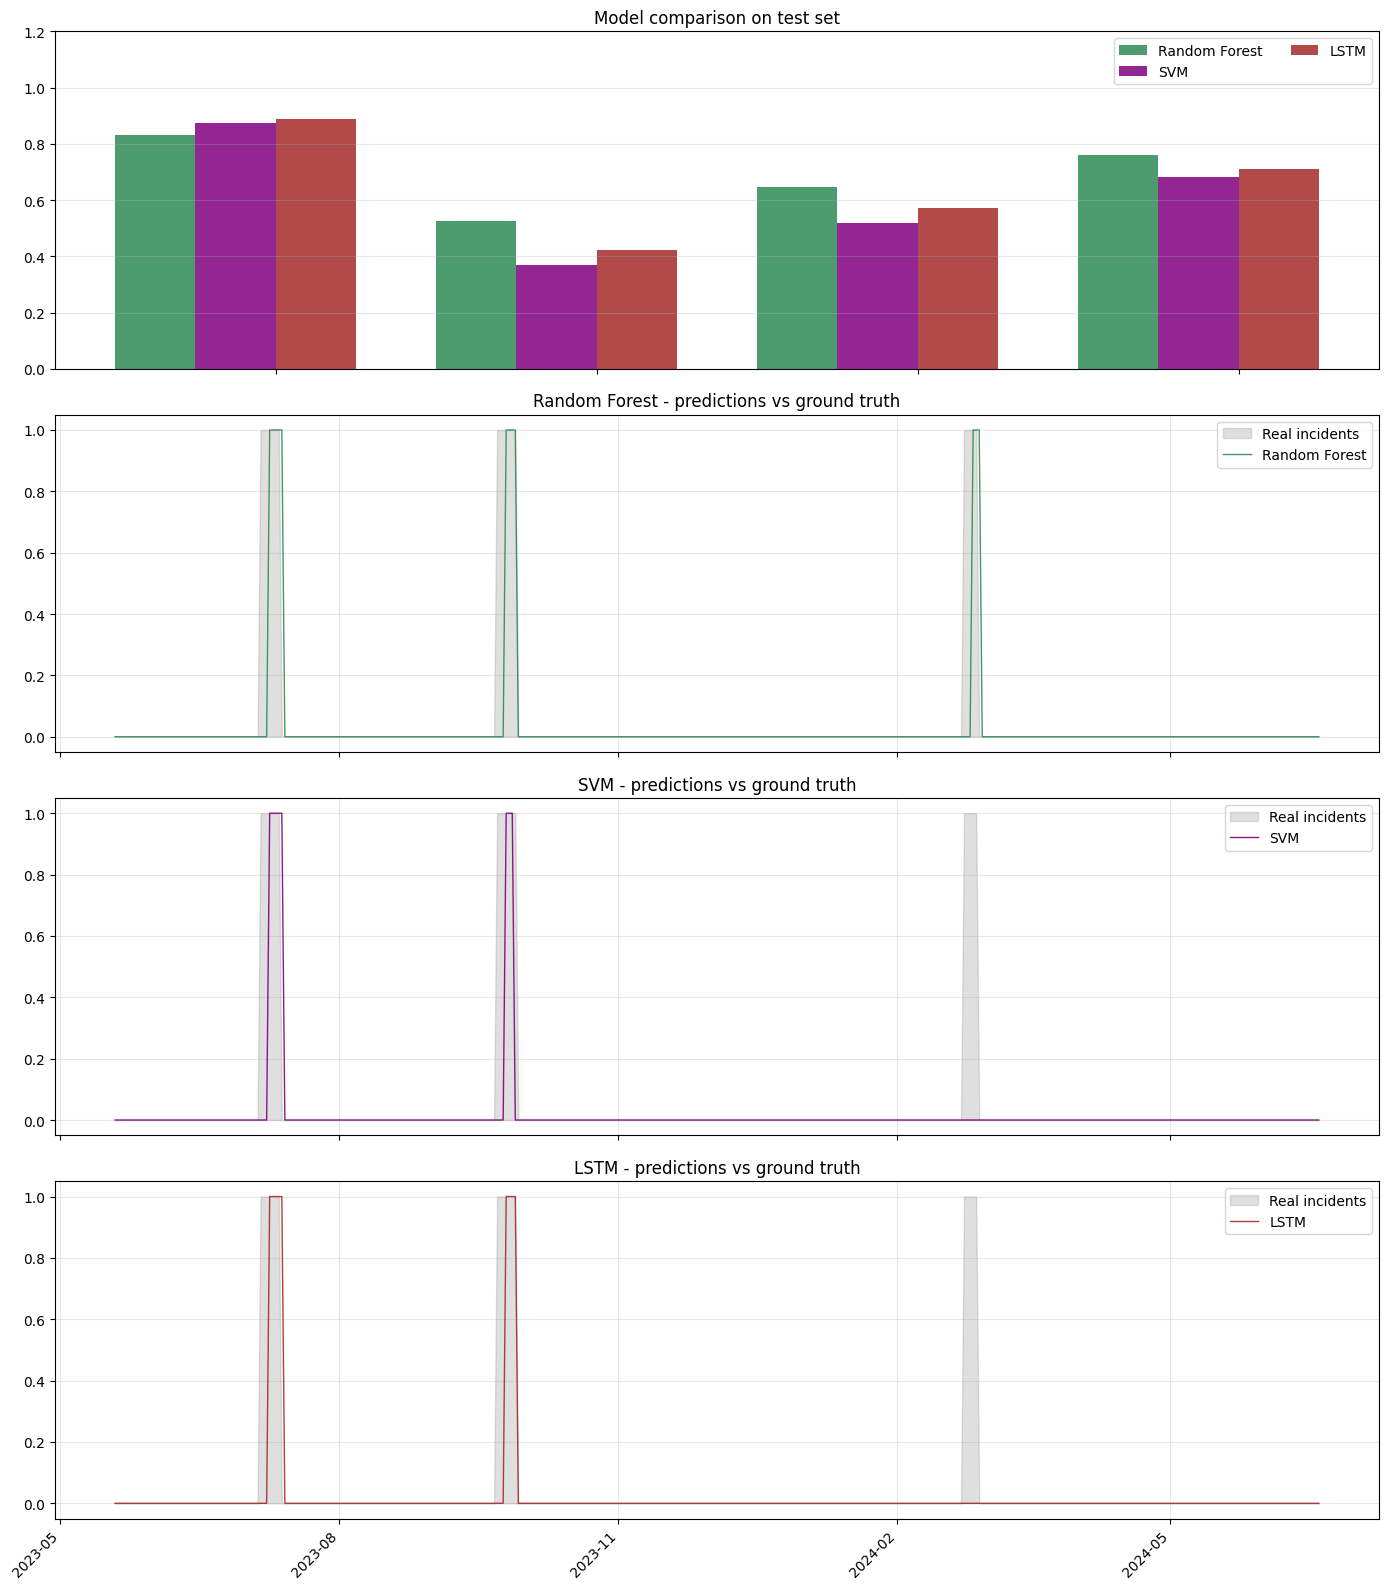

In [13]:
colors = ['seagreen', 'purple', 'brown', 'steelblue']

fig, axes = plt.subplots(len(all_models) + 1, 1, figsize=(14, 4 * (len(all_models) + 1)))

x = np.arange(4)
width = 1 / (len(all_models) + 1)

for i, (name, _) in enumerate(all_models):
    vals = metrics_df.loc[name, ['Precision', 'Recall', 'F1', 'ROC-AUC']].values
    axes[0].bar(x + i * width, vals, width, label=name, color=colors[i], alpha=0.85)

axes[0].set_xticks(x + width * len(all_models) / 2)
axes[0].set_xticklabels(['Precision', 'Recall', 'F1', 'ROC-AUC'])
axes[0].set_ylim(0, 1.2)
axes[0].set_title('Model comparison on test set')
axes[0].legend(ncol=2)
axes[0].grid(axis='y', alpha=0.3)

for ax, (name, preds), color in zip(axes[1:], all_models, colors):
    ax.fill_between(dates_test, y_test, alpha=0.25, color='gray', label='Real incidents')
    ax.plot(dates_test, preds, color=color, linewidth=1, alpha=0.9, label=name)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.set_title(f'{name} - predictions vs ground truth')
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)

fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.savefig('results.png', dpi=150, bbox_inches='tight')
plt.show()